In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully.")

Libraries imported successfully.


In [11]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"Training shape: {train_df.shape}")
print(f"Testing shape: {test_df.shape}")
display(train_df.head())

print()

print(f'Train seasons: {train_df['Seasons'].unique()}')
print(f'Test seasons: {test_df['Seasons'].unique()}')

Training shape: (6576, 15)
Testing shape: (2184, 14)


,Id,Date,Rented_Bike_Count,Hour,Temperature(°C),Humidity(%),Wind speed (m/s),Visibility (10m),Dew point temperature(°C),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Seasons,Holiday,Functioning Day
0,0,01/12/2017,5.541264,0,-5.2,37,2.2,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
1,1,01/12/2017,5.323010,1,-5.5,38,0.8,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
2,2,01/12/2017,5.159055,2,-6.0,39,1.0,2000,-17.7,0.0,0.0,0.0,Winter,No Holiday,Yes
3,3,01/12/2017,4.682131,3,-6.2,40,0.9,2000,-17.6,0.0,0.0,0.0,Winter,No Holiday,Yes
4,4,01/12/2017,4.369448,4,-6.0,36,2.3,2000,-18.6,0.0,0.0,0.0,Winter,No Holiday,Yes



Train seasons: <StringArray>
['Winter', 'Spring', 'Summer']
Length: 3, dtype: str
Test seasons: <StringArray>
['Autumn']
Length: 1, dtype: str


In [13]:
num_cols = ['Hour', 'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)',
            'Visibility (10m)', 'Dew point temperature(°C)',
            'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)']

corr = train_df[num_cols].corrwith(train_df['Rented_Bike_Count']).sort_values(ascending = False)
print('Correlation with target:')
print(corr.round(5))

Correlation with target:
Temperature(°C)              0.54773
Dew point temperature(°C)    0.39136
Hour                         0.33186
Solar Radiation (MJ/m2)      0.32606
Visibility (10m)             0.20310
Wind speed (m/s)             0.08311
Snowfall (cm)               -0.18082
Rainfall(mm)                -0.21553
Humidity(%)                 -0.21826
dtype: float64


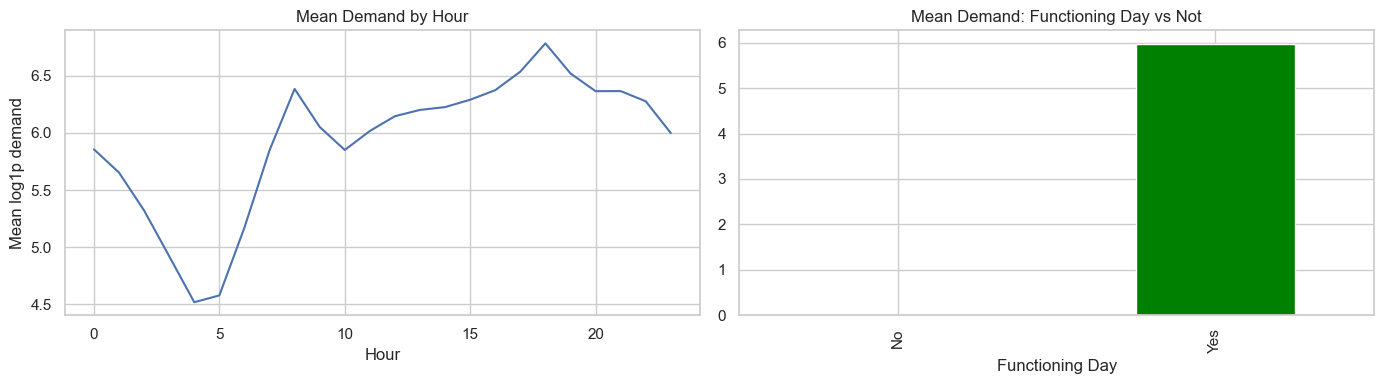

Non-functioning day demand:
count    48.0
mean      0.0
std       0.0
min       0.0
25%       0.0
50%       0.0
75%       0.0
max       0.0
Name: Rented_Bike_Count, dtype: float64


In [14]:
fig, axes = plt.subplots(1, 2, figsize = (14, 4))

train_df.groupby('Hour')['Rented_Bike_Count'].mean().plot(ax = axes[0])
axes[0].set_title('Mean Demand by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Mean log1p demand')

# Functioning Day — should show demand=0 when No
train_df.groupby('Functioning Day')['Rented_Bike_Count'].mean().plot(kind = 'bar', ax = axes[1], color = ['red','green'])
axes[1].set_title('Mean Demand: Functioning Day vs Not')
plt.tight_layout()
plt.show()

print('Non-functioning day demand:')
print(train_df[train_df['Functioning Day'] == 'No']['Rented_Bike_Count'].describe())

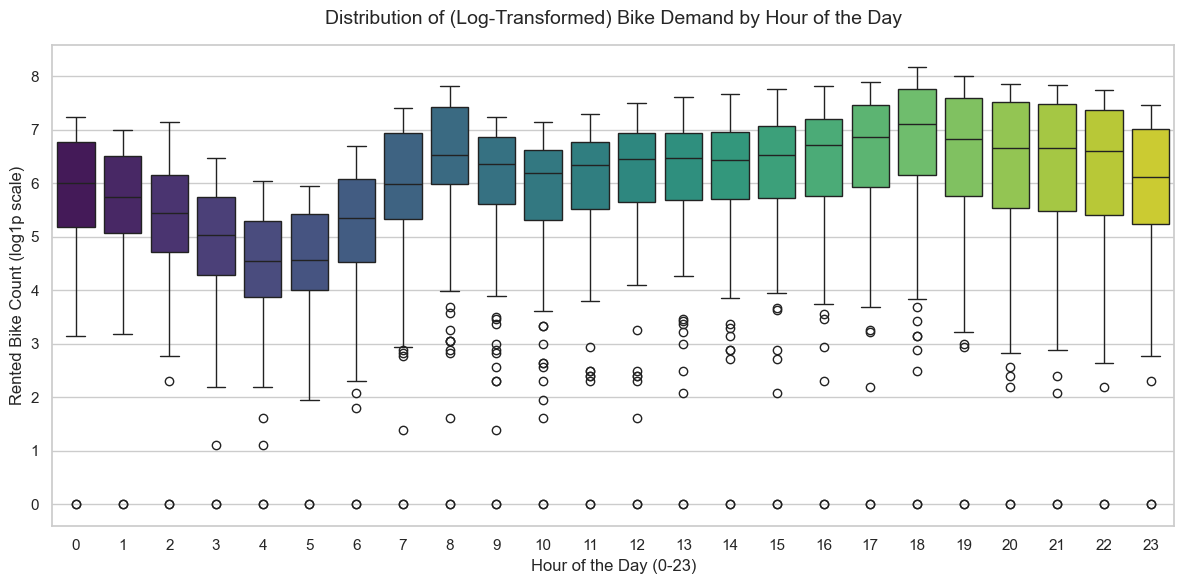

In [15]:
plt.figure(figsize = (12, 6))
sns.boxplot(data = train_df, x = 'Hour', y = 'Rented_Bike_Count', palette = 'viridis')

plt.title('Distribution of (Log-Transformed) Bike Demand by Hour of the Day', fontsize = 14, pad = 15)
plt.xlabel('Hour of the Day (0-23)', fontsize = 12)
plt.ylabel('Rented Bike Count (log1p scale)', fontsize = 12)
plt.tight_layout()
plt.show()

In [17]:
def preprocess_data(df, is_train=True):
    data = df.copy()

    if is_train:
        y = data['Rented_Bike_Count']
    else:
        y = None

    data['Date'] = pd.to_datetime(data["Date"], format = "%d/%m/%Y")
    day = data['Date'].dt.dayofweek
    data['Month'] = data['Date'].dt.month      
    data['DayOfWeek'] = data['Date'].dt.dayofweek  
    data['IsWeekend'] = (data['DayOfWeek'] >= 5).astype(int)

    data['hour_sin'] = np.sin(2 * np.pi * data['Hour'] / 24)
    data['hour_cos'] = np.cos(2 * np.pi * data['Hour'] / 24)
    data['month_sin'] = np.sin(2 * np.pi * data['Month'] / 12)
    data['month_cos'] = np.cos(2 * np.pi * data['Month'] / 12)

    data['is_morning_rush'] = data['Hour'].isin([7, 8, 9]).astype(int)
    data['is_evening_rush'] = data['Hour'].isin([17, 18, 19]).astype(int)
    data['is_rush_hour'] = (data['is_morning_rush'] | data['is_evening_rush']).astype(int)

    data['functioning_day_flag'] = (data['Functioning Day'] == 'Yes').astype(int)
    data['is_holiday'] = (data['Holiday'] == 'Holiday').astype(int)
    data['rush_x_temp'] = data['is_rush_hour'] * data['Temperature(°C)']

    data['rain_flag'] = (data['Rainfall(mm)'] > 0).astype(int)
    data['snow_flag'] = (data['Snowfall (cm)'] > 0).astype(int)
    data['bad_weather'] = (data['rain_flag'] | data['snow_flag']).astype(int)

    data['rush_x_bad_weather'] = data['is_rush_hour'] * data['bad_weather']
    data['temp_comfortable'] = ((data['Temperature(°C)'] >= 10) & (data['Temperature(°C)'] <= 25)).astype(int)
    
    data['is_summer'] = (data['Seasons'] == 'Summer').astype(int)
    data['is_winter'] = (data['Seasons'] == 'Winter').astype(int)
    data['is_spring'] = (data['Seasons'] == 'Spring').astype(int)
    data['is_autumn'] = (data['Seasons'] == 'Autumn').astype(int)

    data["Temp_sq"] = data["Temperature(°C)"] ** 2
    data["Humidity_sq"] = data["Humidity(%)"] ** 2
    data["Wind_sq"] = data["Wind speed (m/s)"] ** 2
    data["Rain_sq"] = data["Rainfall(mm)"] ** 2
    data["Snow_sq"] = data["Snowfall (cm)"] ** 2
    
    drop = ['Id', 'Date', 'Holiday', 'Functioning Day', 'Hour', 'Month', 'DayOfWeek', 'Seasons']
    if is_train:
        drop.append('Rented_Bike_Count')  

    features = data.drop(columns=drop)
    return features, y


X, y = preprocess_data(train_df)
X_test, _ = preprocess_data(test_df, is_train=False)

print('Train features:', list(X.columns))
print()
print('Columns match train == test:', list(X.columns) == list(X_test.columns))
print('Total features:', X.shape[1])

Train features: ['Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Dew point temperature(°C)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'IsWeekend', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'functioning_day_flag', 'is_holiday', 'rush_x_temp', 'rain_flag', 'snow_flag', 'bad_weather', 'rush_x_bad_weather', 'temp_comfortable', 'is_summer', 'is_winter', 'is_spring', 'is_autumn', 'Temp_sq', 'Humidity_sq', 'Wind_sq', 'Rain_sq', 'Snow_sq']

Columns match train == test: True
Total features: 33


In [18]:
split = int(len(X) * 0.8)
X_train = X.iloc[:split]
X_val = X.iloc[split:]
y_train = y.iloc[:split]
y_val = y.iloc[split:]

print(f'Train rows: {len(X_train)}, Val rows: {len(X_val)}')

Train rows: 5260, Val rows: 1316


In [19]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)  
X_val_sc = scaler.transform(X_val)        
X_test_sc = scaler.transform(X_test)       

print('Scaling done.')
print(f'X_train_sc shape: {X_train_sc.shape}')

Scaling done.
X_train_sc shape: (5260, 33)


In [23]:
model = Ridge(alpha=10)
model.fit(X_train_sc, y_train)

val_predictions = model.predict(X_val_sc)
rmse  = root_mean_squared_error(y_val, val_predictions)
print(f'RMSE: {rmse:.4f}')

RMSE: 0.6620


In [24]:
coef_df = pd.Series(model.coef_, index = X.columns).abs().sort_values(ascending = False)
print('Top 10 most influential features:')
print(coef_df.head(10).round(4))

Top 10 most influential features:
Humidity_sq             0.7798
functioning_day_flag    0.6244
Temperature(°C)         0.5321
Humidity(%)             0.5186
hour_sin                0.4598
bad_weather             0.3678
snow_flag               0.2980
Rainfall(mm)            0.2668
is_morning_rush         0.2422
Rain_sq                 0.1844
dtype: float64


In [25]:
scaler_final = StandardScaler()

X_full_sc = scaler_final.fit_transform(X)
X_test_sc = scaler_final.transform(X_test)

ridge = Ridge(alpha = 10)
ridge.fit(X_full_sc, y)

test_predictions = ridge.predict(X_test_sc)

ans = test_df["Functioning Day"] == "No"
test_predictions[ans] = 0

print('Predictions after fixing non-functioning days:')
print('Negative predictions remaining:', (test_predictions < 0).sum())
print('Zero predictions (non-functioning):', (test_predictions == 0.0).sum())

Predictions after fixing non-functioning days:
Negative predictions remaining: 0
Zero predictions (non-functioning): 247
